In [7]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Available training results
results_dir = Path('/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_results_local')
available_runs = sorted([d for d in results_dir.iterdir() if d.is_dir()])

print("Available training runs:")
for i, run in enumerate(available_runs):
    label = run.name  # Remove timestamp (YYYYMMDD-HHMMSS-)
    print(f"  [{i}] {label} ({run.name})")

print(f"\n✓ Loaded {len(available_runs)} available runs")

Available training runs:
  [0] ablation-all-combined-20260403-171108 (ablation-all-combined-20260403-171108)
  [1] ablation-baseline-20260403-164959 (ablation-baseline-20260403-164959)
  [2] ablation-dyn1.0-20260327-141345 (ablation-dyn1.0-20260327-141345)
  [3] ablation-dyn1.0-20260327-153959 (ablation-dyn1.0-20260327-153959)
  [4] ablation-dyn2.0-20260403-170145 (ablation-dyn2.0-20260403-170145)
  [5] ablation-physics1-20260327-135635 (ablation-physics1-20260327-135635)
  [6] ablation-physics1-20260327-153857 (ablation-physics1-20260327-153857)
  [7] ablation-rep0.2-20260327-141445 (ablation-rep0.2-20260327-141445)
  [8] bs4 (bs4)
  [9] bs8 (bs8)
  [10] dreamer-results-20260326-104745-xlargerssm (dreamer-results-20260326-104745-xlargerssm)
  [11] dreamer-reward-v2 (dreamer-reward-v2)
  [12] large_bl32 (large_bl32)
  [13] large_bl32_rewardsv2 (large_bl32_rewardsv2)
  [14] large_bl64 (large_bl64)
  [15] large_bl64_rewardsv2 (large_bl64_rewardsv2)
  [16] medium-ac-xlargerssm (medium-ac-

In [18]:
import yaml

# Load ALL config files at once
all_configs = {}
for idx, run_path in enumerate(available_runs):
    config_file = run_path / 'config.yaml'
    if config_file.exists():
        with open(config_file, 'r') as f:
            all_configs[idx] = {
                'path': run_path,
                'label': run_path.name,
                'config': yaml.safe_load(f)
            }

print(f"✓ Loaded {len(all_configs)} config files")

# Helper to extract nested values
def get_nested(d, key):
    """Get value from nested dict using dot notation (e.g., 'run.train_ratio')"""
    keys = key.split('.')
    val = d
    for k in keys:
        if isinstance(val, dict):
            val = val.get(k)
        else:
            return None
    return val

# Find ALL differences across all configs
def find_all_config_differences(configs_dict):
    """Find all parameters that differ across configs"""
    
    def recurse_all(dict_list, current_path=""):
        all_keys = set()
        for d in [c.get('config', {}) for c in dict_list]:
            if isinstance(d, dict):
                all_keys.update(d.keys())
        
        results = {}
        for key in sorted(all_keys):
            new_path = f"{current_path}.{key}" if current_path else key
            
            # Get values for this parameter across all configs
            values = {}
            all_dicts = {}
            for idx, cfg_data in configs_dict.items():
                d = cfg_data.get('config', {})
                v = d.get(key) if isinstance(d, dict) else None
                values[idx] = v
                all_dicts[idx] = d.get(key) if isinstance(d, dict) else None
            
            # Check if all are dicts (recurse)
            if all(isinstance(v, dict) for v in values.values()):
                nested = recurse_all(
                    [{**cfg_data, 'config': values[idx]} for idx, cfg_data in configs_dict.items()],
                    new_path
                )
                results.update(nested)
            else:
                # Check if there are differences
                unique_values = set(str(v) for v in values.values())
                if len(unique_values) > 1:
                    results[new_path] = values
        
        return results
    
    # Start recursion with original configs
    def full_recurse(configs_dict, current_path=""):
        all_keys = set()
        for idx, cfg_data in configs_dict.items():
            d = cfg_data.get('config', {})
            if isinstance(d, dict):
                all_keys.update(d.keys())
        
        results = {}
        for key in sorted(all_keys):
            new_path = f"{current_path}.{key}" if current_path else key
            values = {}
            next_configs = {}
            
            for idx, cfg_data in configs_dict.items():
                d = cfg_data.get('config', {})
                v = d.get(key) if isinstance(d, dict) else None
                values[idx] = v
                if isinstance(v, dict):
                    next_configs[idx] = {**cfg_data, 'config': v}
            
            # Recurse if all are dicts
            if all(isinstance(v, dict) for v in values.values()) and next_configs:
                nested = full_recurse(next_configs, new_path)
                results.update(nested)
            else:
                # Check for differences
                unique_values = set(str(v) for v in values.values())
                if len(unique_values) > 1:
                    results[new_path] = values
        
        return results
    
    return full_recurse(configs_dict)

all_differences = find_all_config_differences(all_configs)

# Display comprehensive config comparison table
print("\n" + "="*120)
print("CONFIGURATION COMPARISON - ALL RUNS")
print("="*120)

if all_differences:
    # Prepare column headers
    max_label_len = max(len(cfg['label']) for cfg in all_configs.values())
    cols_header = "Parameter".ljust(40)
    for idx in sorted(all_configs.keys()):
        cols_header += f"{all_configs[idx]['label']:<{max_label_len+2}}"
    
    print(f"\n{cols_header}")
    print("-" * 120)
    
    # Display each differing parameter
    for param, values in sorted(all_differences.items()):
        row = param.ljust(40)
        for idx in sorted(values.keys()):
            val_str = str(values[idx])[:max_label_len]
            row += val_str.ljust(max_label_len+2)
        print(row)
    
    print("="*120)
    print(f"\n✓ Found {len(all_differences)} parameters that differ across runs")
else:
    print("\n✓ All configs are identical")

# Now allow selection of two runs for detailed comparison
print("\n" + "="*120)
print("SELECT TWO RUNS FOR DETAILED COMPARISON")
print("="*120)
print("\nAvailable runs:")
for idx in sorted(all_configs.keys()):
    print(f"  [{idx}] {all_configs[idx]['label']}")

print("\n👇 MODIFY THESE TO SELECT RUNS TO COMPARE:")
print("   Set run_indices_to_plot = [1, 2, 3, 4] (modify as needed)")
print("   or use: run_indices_to_plot = [run_idx_1, run_idx_2]\n")

run_indices_to_plot = [12,13,14,15,16,20,21]  # ← Modify this list to select runs

# Helper function to load metrics from a run
def load_metrics(logdir):
    """Load metrics.jsonl from a run directory"""
    metrics_file = logdir / 'metrics.jsonl'
    if metrics_file.exists():
        metrics = []
        with open(metrics_file, 'r') as f:
            for line in f:
                metrics.append(json.loads(line))
        return pd.DataFrame(metrics)
    return None

# Validate and prepare selected runs
valid_indices = [idx for idx in run_indices_to_plot if idx in all_configs]

if valid_indices:
    print(f"✓ Selected for comparison ({len(valid_indices)} runs):")
    for idx in valid_indices:
        print(f"  [{idx}] {all_configs[idx]['label']}")
else:
    print(f"⚠ Invalid indices selected")

# Build run_labels dict
run_labels = {}
for idx in all_configs.keys():
    run_labels[idx] = all_configs[idx]['label']

✓ Loaded 22 config files

CONFIGURATION COMPARISON - ALL RUNS

Parameter                               ablation-all-combined-20260403-171108       ablation-baseline-20260403-164959           ablation-dyn1.0-20260327-141345             ablation-dyn1.0-20260327-153959             ablation-dyn2.0-20260403-170145             ablation-physics1-20260327-135635           ablation-physics1-20260327-153857           ablation-rep0.2-20260327-141445             bs4                                         bs8                                         dreamer-results-20260326-104745-xlargerssm  dreamer-reward-v2                           large_bl32                                  large_bl32_rewardsv2                        large_bl64                                  large_bl64_rewardsv2                        medium-ac-xlargerssm                        rssm_medium-20260403-124004                 rssm_small-20260403-123711                  xlarge_bl32_rewardsv2                       xlarge_bl64      

# Training Results Comparison

## Overview
1. **All Runs Config Diff** - Comprehensive table showing all configuration differences across all your training runs
2. **Detailed Comparison** - Select any 2+ runs to visualize and compare metrics side-by-side with different colors

In cell 2, set `run_indices_to_plot = [1, 2, 3, 4]` to compare any runs you want. All subsequent visualizations and comparisons will use this list.

In [19]:
# HOW TO USE THIS NOTEBOOK:
# 1. Cell 2 loads all configs and displays ALL differences across all runs
# 2. In cell 2, set: run_indices_to_plot = [run_idx_1, run_idx_2]  (modify the list as needed)
#    Examples: [7, 6] or [1, 2, 3, 4] or [0, 5, 7]
# 3. The visualizations below automatically use your selection
#
# To compare more than 2 runs with different colors:
# - Cell 2: run_indices_to_plot = [1, 2, 3, 4]
# That's it! All charts and tables below will show all 4 runs.

✓ Loaded metrics for 7 runs
Visualizing 34 metrics across 8 groups



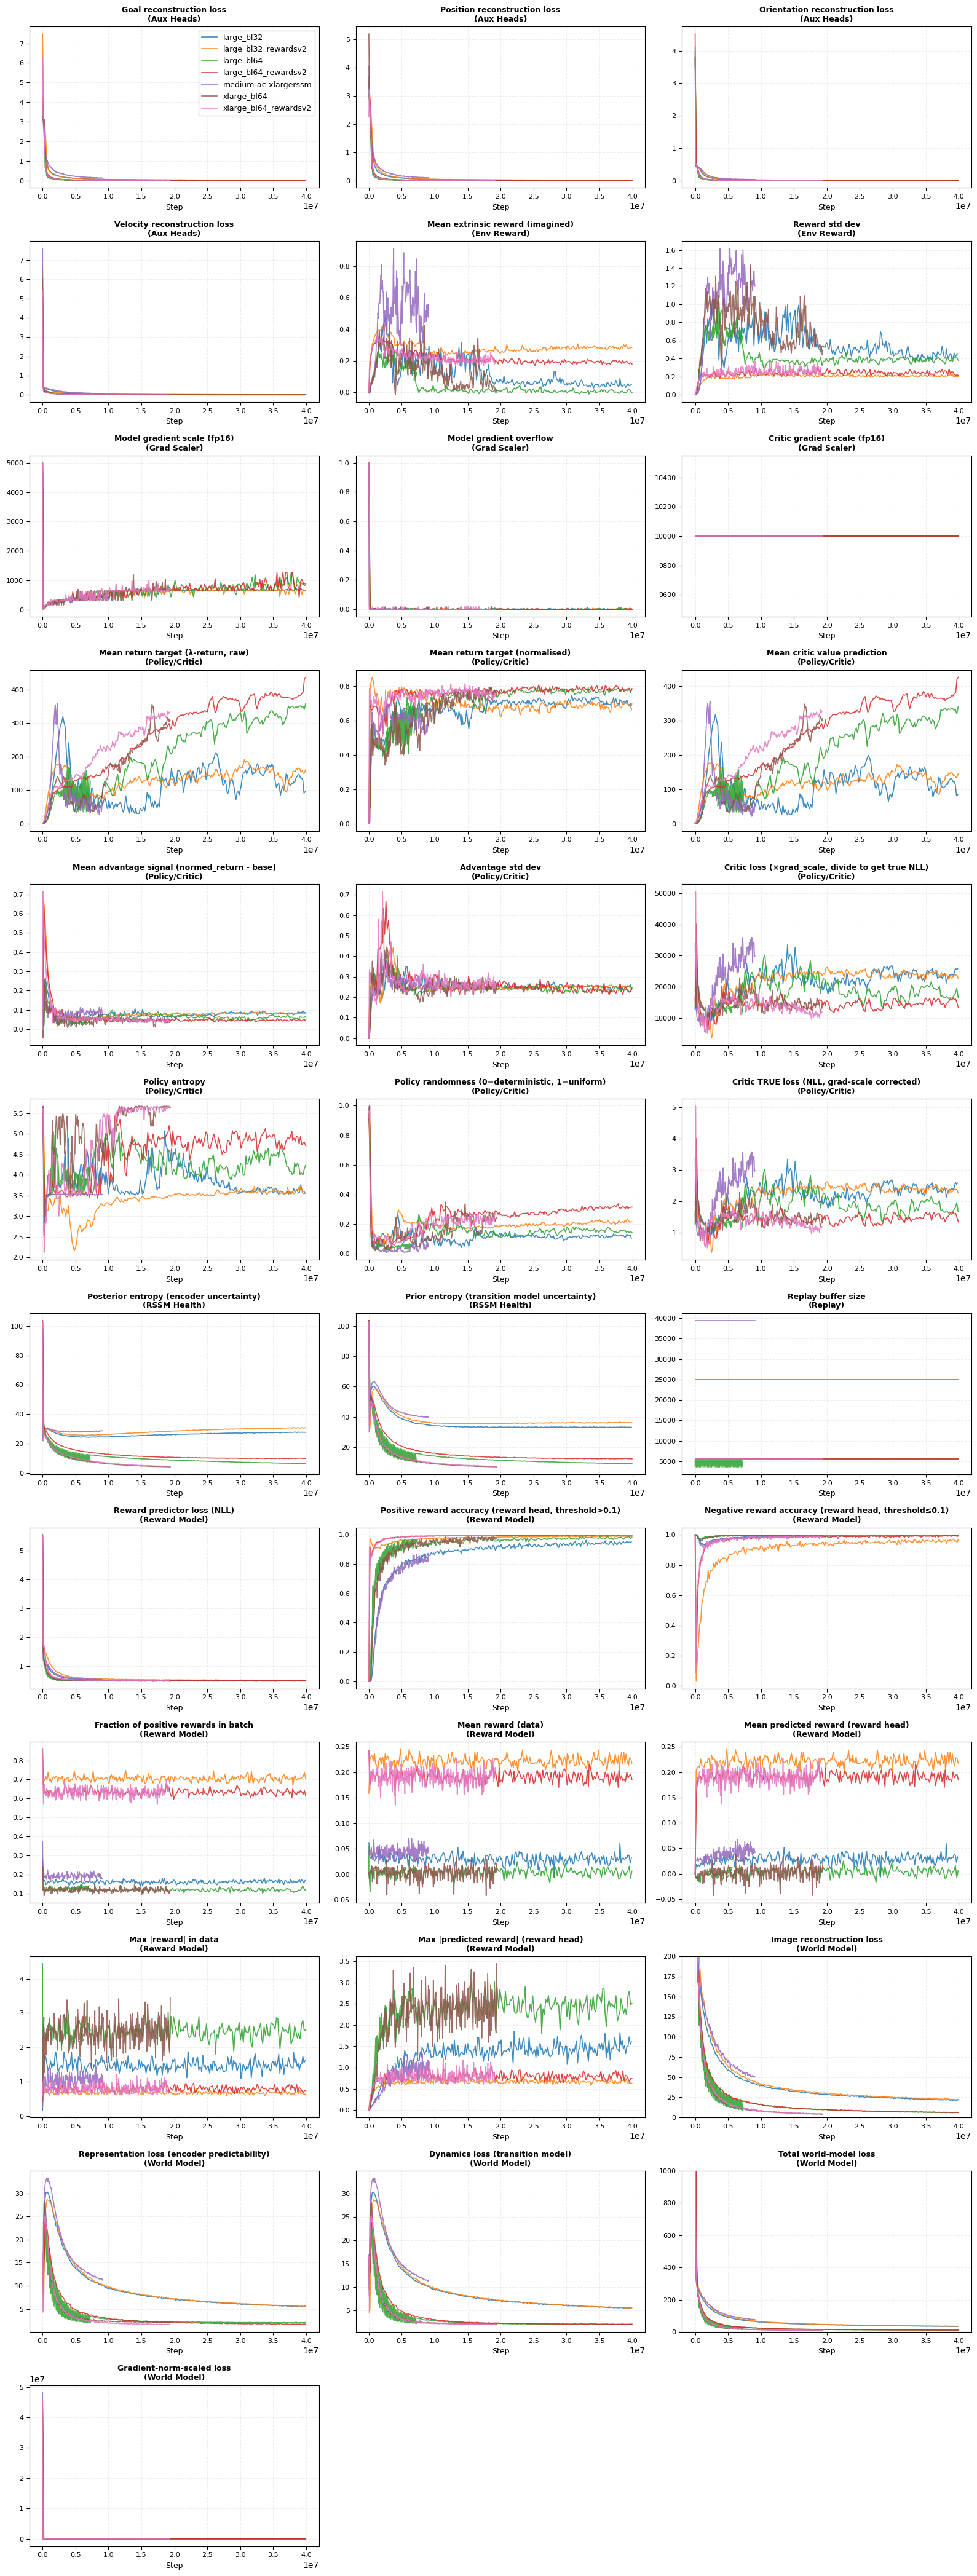


✓ Displayed all 34 metrics from 7 training runs


In [20]:
# Define all metrics to visualize
metric_info = {
    # ── World model ──────────────────────────────────────────────────────────
    "train/image_loss_mean":      ("World Model",   "Image reconstruction loss"),
    "train/rep_loss_mean":        ("World Model",   "Representation loss (encoder predictability)"),
    "train/dyn_loss_mean":        ("World Model",   "Dynamics loss (transition model)"),
    "train/model_loss_mean":      ("World Model",   "Total world-model loss"),
    "train/model_opt_loss":       ("World Model",   "Gradient-norm-scaled loss"),
    # ── RSSM health ───────────────────────────────────────────────────────────
    "train/post_ent_mean":        ("RSSM Health",   "Posterior entropy (encoder uncertainty)"),
    "train/prior_ent_mean":       ("RSSM Health",   "Prior entropy (transition model uncertainty)"),
    # ── Auxiliary heads ──────────────────────────────────────────────────────
    "train/goal_loss_mean":       ("Aux Heads",     "Goal reconstruction loss"),
    "train/position_loss_mean":   ("Aux Heads",     "Position reconstruction loss"),
    "train/orientation_loss_mean":("Aux Heads",     "Orientation reconstruction loss"),
    "train/velocity_loss_mean":   ("Aux Heads",     "Velocity reconstruction loss"),
    "train/terrain_loss_mean":    ("Aux Heads",     "Terrain reconstruction loss"),
    # ── Reward model ─────────────────────────────────────────────────────────
    "train/reward_loss_mean":     ("Reward Model",  "Reward predictor loss (NLL)"),
    "train/reward_pos_acc":       ("Reward Model",  "Positive reward accuracy (reward head, threshold>0.1)"),
    "train/reward_neg_acc":       ("Reward Model",  "Negative reward accuracy (reward head, threshold≤0.1)"),
    "train/reward_rate":          ("Reward Model",  "Fraction of positive rewards in batch"),
    "train/reward_avg":           ("Reward Model",  "Mean reward (data)"),
    "train/reward_pred":          ("Reward Model",  "Mean predicted reward (reward head)"),
    "train/reward_max_data":      ("Reward Model",  "Max |reward| in data"),
    "train/reward_max_pred":      ("Reward Model",  "Max |predicted reward| (reward head)"),
    # ── Policy & critic ──────────────────────────────────────────────────────
    "train/extr_reward_mean":     ("Env Reward",    "Mean extrinsic reward (imagined)"),
    "train/extr_reward_std":      ("Env Reward",    "Reward std dev"),
    "train/extr_return_raw_mean": ("Policy/Critic", "Mean return target (λ-return, raw)"),
    "train/extr_return_normed_mean": ("Policy/Critic", "Mean return target (normalised)"),
    "train/extr_critic_mean":     ("Policy/Critic", "Mean critic value prediction"),
    "train/adv_mean":             ("Policy/Critic", "Mean advantage signal (normed_return - base)"),
    "train/adv_std":              ("Policy/Critic", "Advantage std dev"),
    "train/extr_critic_critic_opt_loss": ("Policy/Critic", "Critic loss (×grad_scale, divide to get true NLL)"),
    "train/policy_entropy_mag":   ("Policy/Critic", "Policy entropy"),
    "train/policy_randomness_mean": ("Policy/Critic", "Policy randomness (0=deterministic, 1=uniform)"),
    # ── Training health ──────────────────────────────────────────────────────
    "train/model_opt_model_opt_grad_scale":    ("Grad Scaler", "Model gradient scale (fp16)"),
    "train/model_opt_model_opt_grad_overflow": ("Grad Scaler", "Model gradient overflow"),
    "train/extr_critic_critic_opt_critic_opt_grad_scale": ("Grad Scaler", "Critic gradient scale (fp16)"),
    "replay/size":                ("Replay",        "Replay buffer size"),
}

# Load metrics for selected runs
# Uses run_indices_to_plot defined in cell 2 above
# To compare different runs, modify cell 2: run_indices_to_plot = [1, 2, 3, 4]

# Color scheme for multiple runs
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
run_data = {}
run_labels_viz = {}

for i, run_idx in enumerate(run_indices_to_plot):
    if run_idx in all_configs:
        run_path = all_configs[run_idx]['path']
        run_labels_viz[run_idx] = all_configs[run_idx]['label']
        
        metrics_file = run_path / 'metrics.jsonl'
        if metrics_file.exists():
            metrics = []
            with open(metrics_file, 'r') as f:
                for line in f:
                    metrics.append(json.loads(line))
            df = pd.DataFrame(metrics)
            # Compute true critic loss: reported loss is multiplied by grad_scale for fp16
            # Divide it back out to get the actual NLL value
            scale_col = 'train/extr_critic_critic_opt_critic_opt_grad_scale'
            loss_col = 'train/extr_critic_critic_opt_loss'
            if loss_col in df.columns and scale_col in df.columns:
                df['train/extr_critic_true_loss'] = df[loss_col] / df[scale_col]
            run_data[run_idx] = df

print(f"✓ Loaded metrics for {len(run_data)} runs")

# Add derived metric to info dict
metric_info['train/extr_critic_true_loss'] = ("Policy/Critic", "Critic TRUE loss (NLL, grad-scale corrected)")

# Filter metrics that exist in at least one run
available_metrics = [col for col in metric_info.keys() 
                     if any(col in run_data[idx].columns for idx in run_data.keys())]
available_metrics.sort(key=lambda x: metric_info[x][0])

print(f"Visualizing {len(available_metrics)} metrics across {len(set(m[0] for m in metric_info.values()))} groups\n")

# Create grid: 3 columns x n rows
ncols = 3
nrows = (len(available_metrics) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5*nrows))
if nrows == 1 and ncols == 1:
    axes = np.array([axes])  # Handle single subplot case
axes = axes.flatten()

for idx, metric_col in enumerate(available_metrics):
    ax = axes[idx]
    group, short_desc = metric_info[metric_col]
    
    # Plot all selected runs with different colors
    for i, run_idx in enumerate(run_indices_to_plot):
        if run_idx in run_data and metric_col in run_data[run_idx].columns:
            df = run_data[run_idx]
            color = colors[i % len(colors)]
            ax.plot(df['step'], df[metric_col], linewidth=1.2, color=color, 
                   label=run_labels_viz[run_idx], alpha=0.85)
    
    # Format plot
    ax.set_title(f"{short_desc}\n({group})", fontsize=9, fontweight='bold')
    ax.set_xlabel('Step', fontsize=9)
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.tick_params(axis='both', which='major', labelsize=8)
    
    # Set y-axis limits for specific metrics to zoom in on convergence
    if metric_col in ['train/image_loss_mean']:
        ax.set_ylim(0, 200)

    if metric_col in ['train/model_loss_mean']:
        ax.set_ylim(0, 1000)
    
    # Add legend only to first plot
    if idx == 0:
        ax.legend(loc='best', fontsize=9, framealpha=0.95)

# Hide unused subplots
for idx in range(len(available_metrics), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\n✓ Displayed all {len(available_metrics)} metrics from {len(run_indices_to_plot)} training runs")


In [21]:

# Compare final metric values between selected runs
print("\n" + "="*120)
print(f"FINAL METRIC VALUES COMPARISON - {len(run_indices_to_plot)} RUNS")
print("="*120)

# Build header dynamically
header = f"{'Metric':<45}"
for run_idx in run_indices_to_plot:
    header += f"{run_labels[run_idx]:<25}"
print(f"\n{header}")
print("-"*120)

# Build comparison table
for metric_col in sorted(available_metrics):
    group, short_desc = metric_info[metric_col]
    row = f"{short_desc:<45}"
    
    values_list = []
    for run_idx in run_indices_to_plot:
        if run_idx in run_data and metric_col in run_data[run_idx].columns:
            val = run_data[run_idx][metric_col].iloc[-1]
            values_list.append(val)
            row += f"{val:>24.6f}"
        else:
            row += f"{'(missing)':>24}"
    
    # Add comparison marker for 2-run case
    if len(values_list) == 2:
        val_1, val_2 = values_list
        if metric_col in ['train/extr_reward_mean', 'train/reward_pos_acc', 'train/reward_neg_acc']:
            marker = " ↑" if val_2 > val_1 else " ↓"
        else:
            marker = " ✓" if val_2 < val_1 else " ✗"
        row += marker
    
    print(row)

print("="*120)
print("\nMarkers (2-run comparison only):")
print("↑ = Run 2 is better (higher reward, higher accuracy)")
print("↓ = Run 1 is better (higher reward, higher accuracy)")
print("✓ = Run 2 is better (lower loss)")
print("✗ = Run 1 is better (lower loss)")
print("="*120)

print(f"\n📊 TRAINING RUNS SELECTED")
for run_idx in run_indices_to_plot:
    print(f"   • {run_labels[run_idx]}: {len(run_data[run_idx]) if run_idx in run_data else 0} checkpoints")


FINAL METRIC VALUES COMPARISON - 7 RUNS

Metric                                       large_bl32               large_bl32_rewardsv2     large_bl64               large_bl64_rewardsv2     medium-ac-xlargerssm     xlarge_bl64              xlarge_bl64_rewardsv2    
------------------------------------------------------------------------------------------------------------------------
Replay buffer size                                       25009.000000            25009.000000             5570.000000             5570.000000            39479.000000             5570.000000             5570.000000
Mean advantage signal (normed_return - base)                 0.086015                0.081051                0.067268                0.043765                0.082099                0.038548                0.042648
Advantage std dev                                            0.240819                0.247664                0.245101                0.241678                0.242083                0.25582

In [22]:
# All training runs overview - comprehensive metrics
import pandas as pd

print("\n" + "="*200)
print("ALL TRAINING RUNS - COMPREHENSIVE METRICS OVERVIEW")
print("="*200)

all_runs_data = []

# Metrics to extract for each run
metrics_to_track = {
    'train/extr_reward_mean': 'Final Reward',
    'train/model_loss_mean': 'Model Loss',
    'train/image_loss_mean': 'Image Loss',
    'train/rep_loss_mean': 'Rep Loss',
    'train/dyn_loss_mean': 'Dyn Loss',
    'train/reward_loss_mean': 'Reward Loss',
    'train/reward_pos_acc': 'Reward Pos Acc',
    'train/reward_neg_acc': 'Reward Neg Acc',
    'train/velocity_loss_mean': 'Velocity Loss',
    'train/position_loss_mean': 'Position Loss',
    'train/goal_loss_mean': 'Goal Loss',
    'train/terrain_loss_mean': 'Terrain Loss',
    'train/policy_entropy_mag': 'Policy Entropy',
    'train/model_opt_model_opt_grad_scale': 'Grad Scale',
}

for run_idx, run_path in enumerate(available_runs):
    label = run_path.name  # Extract label
    
    # Load metrics
    df = load_metrics(run_path)
    
    if df is not None:
        run_data = {'label': label, 'run_idx': run_idx, 'checkpoints': len(df)}
        
        # Extract all metrics (final values)
        for metric_key, metric_name in metrics_to_track.items():
            if metric_key in df.columns:
                run_data[metric_name] = df[metric_key].iloc[-1]
            else:
                run_data[metric_name] = np.nan
        
        all_runs_data.append(run_data)

# Convert to DataFrame for nice display
if all_runs_data:
    df_summary = pd.DataFrame(all_runs_data)
    
    # Display full table
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None)
    
    # Create display dataframe with selected columns
    display_cols = ['label', 'checkpoints'] + list(metrics_to_track.values())
    df_display = df_summary[display_cols].copy()
    df_display = df_display.round(4)
    
    print("\n" + df_display.to_string(index=False))
    print("\n" + "="*200)
    
    # Top performers rankings
    print("\n🏆 TOP PERFORMERS BY METRIC:\n")
    
    print("  Best Final Reward:")
    top_reward = df_summary.nlargest(3, 'Final Reward')[['label', 'Final Reward']]
    for i, (idx, row) in enumerate(top_reward.iterrows(), 1):
        print(f"    {i}. {row['label']:<50} → {row['Final Reward']:.6f}")
    
    print("\n  Lowest Model Loss:")
    best_loss = df_summary.nsmallest(3, 'Model Loss')[['label', 'Model Loss']]
    for i, (idx, row) in enumerate(best_loss.iterrows(), 1):
        print(f"    {i}. {row['label']:<50} → {row['Model Loss']:.6f}")
    
    print("\n  Best Reward Accuracy (Pos):")
    best_reward_acc = df_summary.nlargest(3, 'Reward Pos Acc')[['label', 'Reward Pos Acc']]
    for i, (idx, row) in enumerate(best_reward_acc.iterrows(), 1):
        print(f"    {i}. {row['label']:<50} → {row['Reward Pos Acc']:.6f}")
    
    print("\n  Lowest Image Loss:")
    best_img_loss = df_summary.nsmallest(3, 'Image Loss')[['label', 'Image Loss']]
    for i, (idx, row) in enumerate(best_img_loss.iterrows(), 1):
        print(f"    {i}. {row['label']:<50} → {row['Image Loss']:.6f}")
    
    print("\n  Lowest Terrain Loss:")
    best_terrain_loss = df_summary.nsmallest(3, 'Terrain Loss')[['label', 'Terrain Loss']]
    for i, (idx, row) in enumerate(best_terrain_loss.iterrows(), 1):
        if not np.isnan(row['Terrain Loss']):
            print(f"    {i}. {row['label']:<50} → {row['Terrain Loss']:.6f}")
else:
    print("No runs to display")



ALL TRAINING RUNS - COMPREHENSIVE METRICS OVERVIEW

                                     label  checkpoints  Final Reward  Model Loss  Image Loss  Rep Loss  Dyn Loss  Reward Loss  Reward Pos Acc  Reward Neg Acc  Velocity Loss  Position Loss  Goal Loss  Terrain Loss  Policy Entropy  Grad Scale
     ablation-all-combined-20260403-171108          191        0.3323     79.9126     42.5732   12.4285   12.4285       0.5427          0.8285          0.9840         0.0597         0.0701     0.0625           NaN          3.5456    282.3483
         ablation-baseline-20260403-164959          191        0.0796     33.1038     26.0688   10.3178   10.3178       0.5137          0.9031          0.9857         0.0312         0.0332     0.0313           NaN          3.5789    636.5031
           ablation-dyn1.0-20260327-141345          122        0.0967     70.3330     44.7282    9.8537    9.8537       0.5223          0.8616          0.9849         0.0425         0.0481     0.0409           NaN        

# Observation Variance & Redundancy Analysis

Analyzes every observation channel across the full dataset to identify:
- **Near-constant channels** (low variance → waste of model capacity)
- **Redundant channels** (can be derived from other channels)
- **Position vs Goal relationship** (both in world frame from episode start)


Found 1 episodes  (/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_SPOT_implementation/informed-dreamer/processed_data)
Total timesteps: 91  across 1 episodes

Channel              Key                    Mean      Std      Min      Max     ~0%  Note
----------------------------------------------------------------------------------------------------
  pos_x              position[0]          -2.962   1.9931   -6.496    0.063   12.1%  world frame
  pos_y              position[1]          -1.462   1.6282   -4.408    0.836    8.8%  world frame
  pos_z              position[2]           0.059   0.0331   -0.006    0.116   34.1%  height ◄ LOW VARIANCE
  quat_x→roll        orientation[0]       -0.004   0.0191   -0.070    0.053   95.6%  → roll ◄ LOW VARIANCE
  quat_y→pitch       orientation[1]        0.002   0.0196   -0.056    0.086   94.5%  → pitch ◄ LOW VARIANCE
  quat_z             orientation[2]        0.161   0.5964   -0.822    1.000   11.0%  yaw component
  quat_w             o

/tmp/ipykernel_1075484/2207450213.py:107: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)


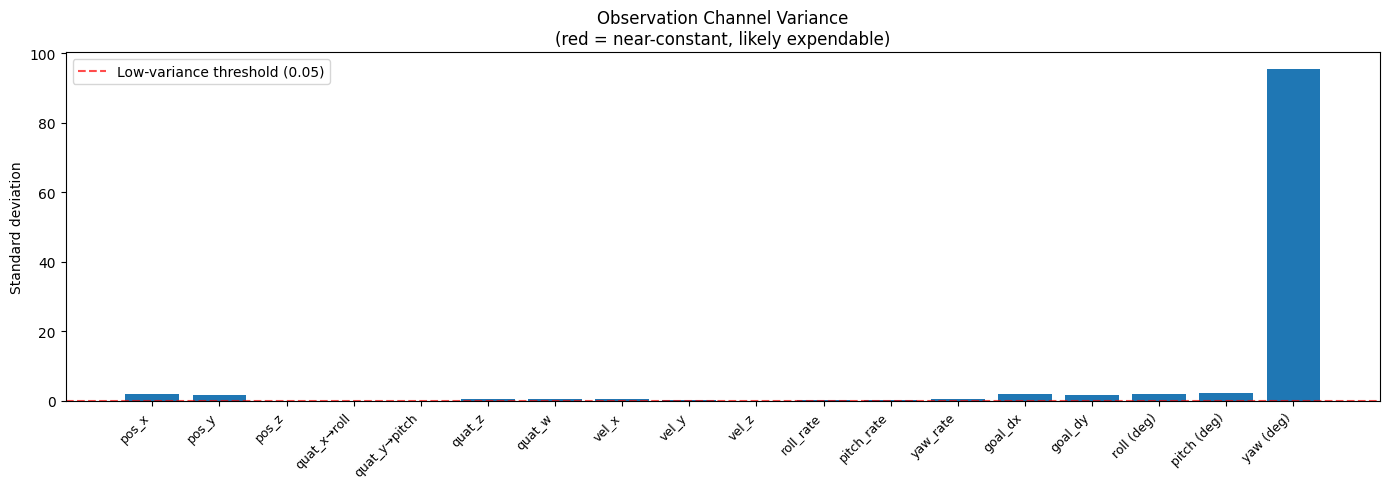


✓ Analysed 91 timesteps from 1 episodes


In [23]:
import h5py
from scipy.stats import pearsonr

# ── Config ────────────────────────────────────────────────────────────────────
# Point this at your actual dataset directory (local or mounted cluster path)
H5_DATA_DIR = Path('/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_SPOT_implementation/informed-dreamer/processed_data')

# ── Load all episodes ─────────────────────────────────────────────────────────
all_states, all_velocities, all_goal_rels = [], [], []

h5_files = sorted(H5_DATA_DIR.glob('**/*.h5'))
print(f"Found {len(h5_files)} episodes  ({H5_DATA_DIR})")

for h5f in h5_files:
    with h5py.File(h5f, 'r') as f:
        states = f['observations/state'][:]       # (T, 7): [x,y,z, qx,qy,qz,qw]
        vels   = f['observations/velocities'][:]  # (T, 6): [vx,vy,vz, wx,wy,wz]
    goal_final_xy = states[-1, :2]
    goal_rel = states[:, :2] - goal_final_xy      # vector pointing from pos to goal
    all_states.append(states)
    all_velocities.append(vels)
    all_goal_rels.append(goal_rel)

states_all   = np.concatenate(all_states, axis=0)
vels_all     = np.concatenate(all_velocities, axis=0)
goal_rel_all = np.concatenate(all_goal_rels, axis=0)

# Derived orientation angles from quaternion
qx, qy, qz, qw = states_all[:,3], states_all[:,4], states_all[:,5], states_all[:,6]
roll  = np.arctan2(2*(qw*qx + qy*qz), 1 - 2*(qx**2 + qy**2))
pitch = np.arcsin(np.clip(2*(qw*qy - qz*qx), -1, 1))
yaw   = np.arctan2(2*(qw*qz + qx*qy), 1 - 2*(qy**2 + qz**2))

N = len(states_all)
print(f"Total timesteps: {N:,}  across {len(h5_files)} episodes\n")

# ── Channel statistics ────────────────────────────────────────────────────────
channels = {
    # name             : (data,  model_key,            dim_label)
    'pos_x'        : (states_all[:,0],  'position[0]',   'world frame'),
    'pos_y'        : (states_all[:,1],  'position[1]',   'world frame'),
    'pos_z'        : (states_all[:,2],  'position[2]',   'height'),
    'quat_x→roll'  : (qx,               'orientation[0]', '→ roll'),
    'quat_y→pitch' : (qy,               'orientation[1]', '→ pitch'),
    'quat_z'       : (qz,               'orientation[2]', 'yaw component'),
    'quat_w'       : (qw,               'orientation[3]', 'yaw component'),
    'vel_x'        : (vels_all[:,0],    'velocity[0]',   'body fwd'),
    'vel_y'        : (vels_all[:,1],    'velocity[1]',   'body lateral'),
    'vel_z'        : (vels_all[:,2],    'velocity[2]',   'body up ← near-const'),
    'roll_rate'    : (vels_all[:,3],    'velocity[3]',   'body roll rate'),
    'pitch_rate'   : (vels_all[:,4],    'velocity[4]',   'body pitch rate'),
    'yaw_rate'     : (vels_all[:,5],    'velocity[5]',   'body yaw rate'),
    'goal_dx'      : (goal_rel_all[:,0],'goal[0]',       'world frame'),
    'goal_dy'      : (goal_rel_all[:,1],'goal[1]',       'world frame'),
    'roll (deg)'   : (roll*180/np.pi,   '(derived)',     ''),
    'pitch (deg)'  : (pitch*180/np.pi,  '(derived)',     ''),
    'yaw (deg)'    : (yaw*180/np.pi,    '(derived)',     ''),
}

print(f"{'Channel':<20} {'Key':<18} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}  {'~0%':>6}  Note")
print("-"*100)
for name, (data, key, note) in channels.items():
    near_zero_pct = (np.abs(data) < 0.05).mean() * 100
    flag = " ◄ LOW VARIANCE" if data.std() < 0.05 else ""
    print(f"  {name:<18} {key:<18} {data.mean():>8.3f} {data.std():>8.4f} {data.min():>8.3f} {data.max():>8.3f}  {near_zero_pct:>5.1f}%  {note}{flag}")

# ── Redundancy: can pos_xy be derived from goal_rel? ─────────────────────────
print(f"\n{'='*60}")
print("REDUNDANCY: pos_xy vs goal_rel (per-episode)")
print(f"{'='*60}")
pos_xy_all = states_all[:, :2]
# Within an episode: pos_xy = goal_final_xy - goal_rel
# Reconstruction: pos_reconstructed = goal_final - goal_rel
# We can check this within episodes
reconstructed = []
actual = []
for states, goal_rel in zip(all_states, all_goal_rels):
    goal_final = states[-1, :2]
    pos_reconstructed = goal_final - goal_rel
    reconstructed.append(pos_reconstructed)
    actual.append(states[:, :2])
rec = np.concatenate(reconstructed); act = np.concatenate(actual)
mse = np.mean((rec - act) ** 2)
print(f"  pos_xy reconstruction from goal_rel: MSE = {mse:.6f}  (should be 0.000 exactly)")
print(f"  → pos_xy is EXACTLY redundant given goal_rel within each episode")
print(f"  → BUT pos_xy encodes absolute world position (unknown goal_final)")
print(f"  → Model can use pos_xy to track where it is, not just how far from goal")

# ── Correlation: does goal_rel predict position change? ──────────────────────
print(f"\n{'='*60}")
print("GOAL PREDICTIVENESS: does goal_rel correlate with reward?")
print(f"{'='*60}")
# dist to goal over time
for states in all_states:
    dist = np.linalg.norm(states[:, :2] - states[-1, :2], axis=1)
print(f"  (run on cluster with full dataset for meaningful correlation)")

# ── Plot variance bars ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
names = list(channels.keys())
stds  = [channels[n][0].std() for n in names]
colors_bar = ['#d62728' if s < 0.05 else '#1f77b4' for s in stds]
bars = ax.bar(names, stds, color=colors_bar)
ax.axhline(0.05, color='red', linestyle='--', alpha=0.7, label='Low-variance threshold (0.05)')
ax.set_ylabel('Standard deviation')
ax.set_title('Observation Channel Variance\n(red = near-constant, likely expendable)')
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n✓ Analysed {N:,} timesteps from {len(h5_files)} episodes")
